In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.stats import norm

In [3]:
# Create dataset
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)

# Add outliers
outliers = np.random.uniform(low=-8, high=8, size=(20, 2))
X = np.vstack((X, outliers))

# Normalize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Parameters
k = 10
lambda_param = 3  # scaling factor

In [4]:
# KNN
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

In [5]:
# Step 1: Probabilistic distance (pdist)
pdist = lambda_param * np.sqrt(np.mean(distances**2, axis=1))

In [6]:
# Step 2: Compute PLOF (Probabilistic Local Outlier Factor)
plof = []

for i in range(len(X_scaled)):
    neighbors = indices[i]
    mean_pdist_neighbors = np.mean(pdist[neighbors])
    
    value = (pdist[i] / (mean_pdist_neighbors + 1e-5)) - 1
    plof.append(value)

plof = np.array(plof)

In [7]:
# Step 3: Normalize using Gaussian error function
nplof = np.std(plof)
loop_scores = norm.cdf(plof / (nplof + 1e-5))

In [8]:
# Detect outliers (probability > 0.7)
threshold = 0.7
normal_points = X[loop_scores <= threshold]
outliers = X[loop_scores > threshold]

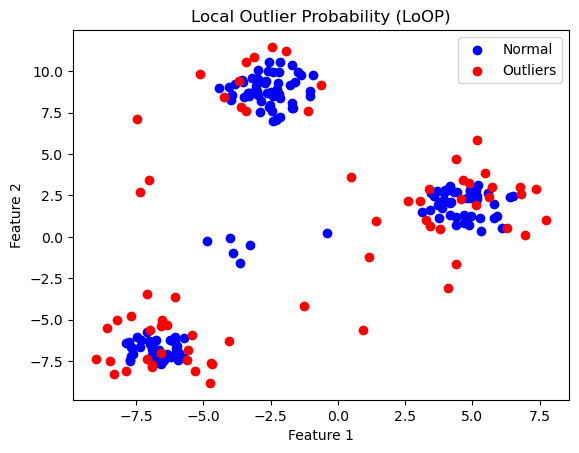

In [9]:
# Plot
plt.scatter(normal_points[:, 0], normal_points[:, 1], color='blue', label='Normal')
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', label='Outliers')

plt.legend()
plt.title("Local Outlier Probability (LoOP)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()